In [3]:
# %load ini.py
# 导入三大神器
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
# 解决字体mac
plt.rcParams['font.sans-serif'] = ['SimHei']  
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

In [47]:
#读取数据
df = pd.read_csv('../共享单车_清洗后.csv')
# 将时间字段转为datetime格式
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 提取日期（用于后续分组）
df['start_date'] = df['start_time'].dt.date

# 查看前几行确认
df.head()

,orderid,bikeid,userid,start_time,start_location_x(°),start_location_y(°),end_time,end_location_x(°),end_location_y(°),track,...,time_period,is_weekend,ride_date,天气,avg_temp(℃),sunshine_h(h),max_temp(℃),min_temp(℃),actual_temp(℃),start_date
0,78387,158357,10080,2016-08-20 06:57:00,121.348,31.389,2016-08-20 07:04:00,121.357,31.388,"121.347,31.392#121.348,31.389#121.349,31.390#1...",...,早高峰(6-9点),1,2016-08-20,晴,31.0,11.9,33.8,28.1,28.1,2016-08-20
1,891333,92776,6605,2016-08-29 19:09:00,121.508,31.279,2016-08-29 19:31:00,121.489,31.271,"121.489,31.270#121.489,31.271#121.490,31.270#1...",...,晚高峰(17-20点),0,2016-08-29,晴,25.2,12.0,29.5,21.0,25.2,2016-08-29
2,1106623,152045,8876,2016-08-13 16:17:00,121.383,31.254,2016-08-13 16:36:00,121.405,31.248,"121.381,31.251#121.382,31.251#121.382,31.252#1...",...,日间(9-17点),1,2016-08-13,晴,29.6,12.0,31.9,27.4,31.9,2016-08-13
3,1389484,196259,10648,2016-08-23 21:34:00,121.484,31.320,2016-08-23 21:43:00,121.471,31.325,"121.471,31.325#121.472,31.325#121.473,31.324#1...",...,夜间(20-6点),0,2016-08-23,晴,28.9,11.9,31.6,26.2,26.2,2016-08-23
4,188537,78208,11735,2016-08-16 07:32:00,121.407,31.292,2016-08-16 07:41:00,121.418,31.288,"121.407,31.291#121.407,31.292#121.408,31.291#1...",...,早高峰(6-9点),0,2016-08-16,晴,29.2,12.0,31.8,26.6,29.2,2016-08-16


## B3 天气影响分析

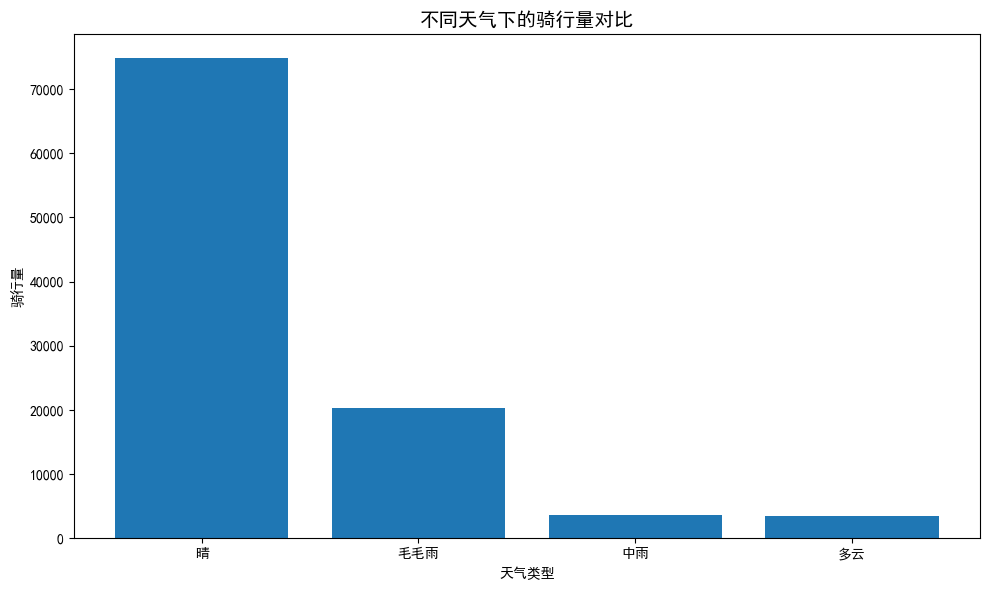

In [48]:
#不同天气的骑行量   晴/雨/阴天差异多大？  柱状图
# 统计每种天气的骑行量
weather_counts = df['天气'].value_counts()
# 绘制柱状图
plt.figure(figsize=(10,6))
bars = plt.bar(weather_counts.index, 
               weather_counts.values
)
plt.title('不同天气下的骑行量对比', fontsize=14)
plt.xlabel('天气类型')
plt.ylabel('骑行量')
plt.tight_layout()
plt.show()

In [18]:
# 创建温度区间：从15℃到35℃，每3℃一组（左闭右开）
bins = list(range(15, 39, 3))          # [15, 18, 21, 24, 27, 30, 33, 36]
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]  # ['15-18', '18-21', ..., '33-36']

df['temp_range'] = pd.cut(df['actual_temp(℃)'], bins=bins, labels=labels, right=False)

# 统计每个温度区间的骑行量
temp_riding = df['temp_range'].value_counts().sort_index()

# 输出透视表
print("温度区间骑行量统计）：")
print(temp_riding)



温度区间骑行量统计）：
temp_range
15-18        0
18-21     2265
21-24     2187
24-27    20870
27-30    49858
30-33    25207
33-36     1823
Name: count, dtype: int64


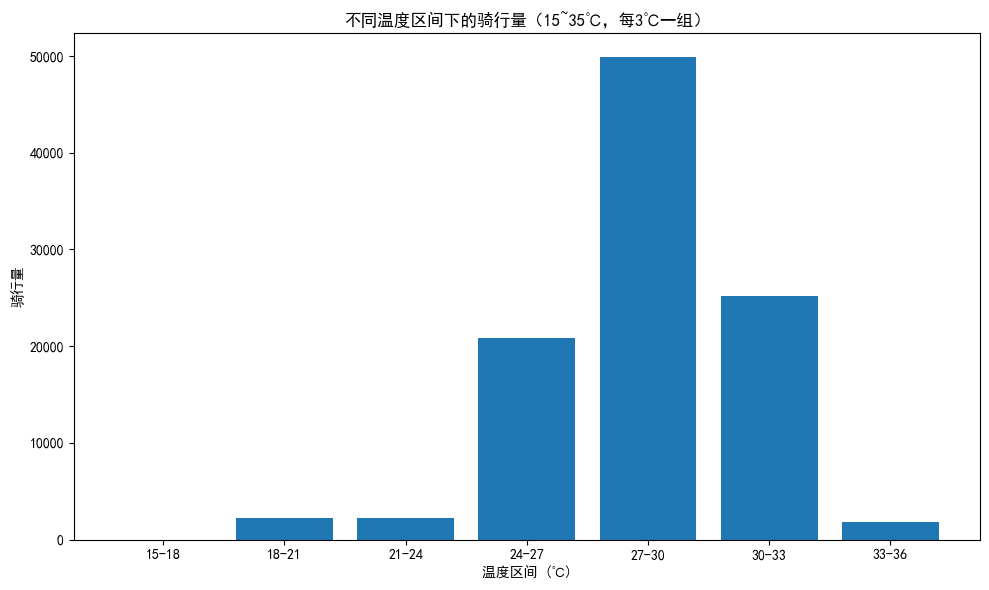

In [19]:
# 绘制柱状图
plt.figure(figsize=(10,6))
bars = plt.bar(temp_riding.index.astype(str), temp_riding.values)
plt.title('不同温度区间下的骑行量（15~35℃，每3℃一组）')
plt.xlabel('温度区间 (℃)')
plt.ylabel('骑行量')
plt.tight_layout()
plt.show()

In [16]:
# 创建透视表：行=小时(start_hour)，列=天气，值=骑行量
hour_weather_pivot = df.pivot_table(
    index='start_hour(h)',
    columns='天气',
    aggfunc='size',
    fill_value=0
)
print(hour_weather_pivot)


天气              中雨   多云     晴   毛毛雨
start_hour(h)                      
0                6   45   697   194
1               10   27   443   125
2               15    8   294    81
3               11    2   181    32
4                2    5   193    31
5               24   15   369   104
6              111   73  1696   410
7              319  237  4709  1037
8              433  361  6181  1502
9              233  176  3803   982
10             134   95  2723   718
11             106  104  2750   735
12              85  101  3072   890
13              78  129  3094   907
14              66   98  2852   941
15              92  131  3222   954
16             136  147  3947  1144
17             403  326  6761  1781
18             233  431  7330  2124
19             334  314  6635  1704
20             324  240  5423  1478
21             247  193  4321  1225
22             151  122  2773   812
23              36   56  1379   426


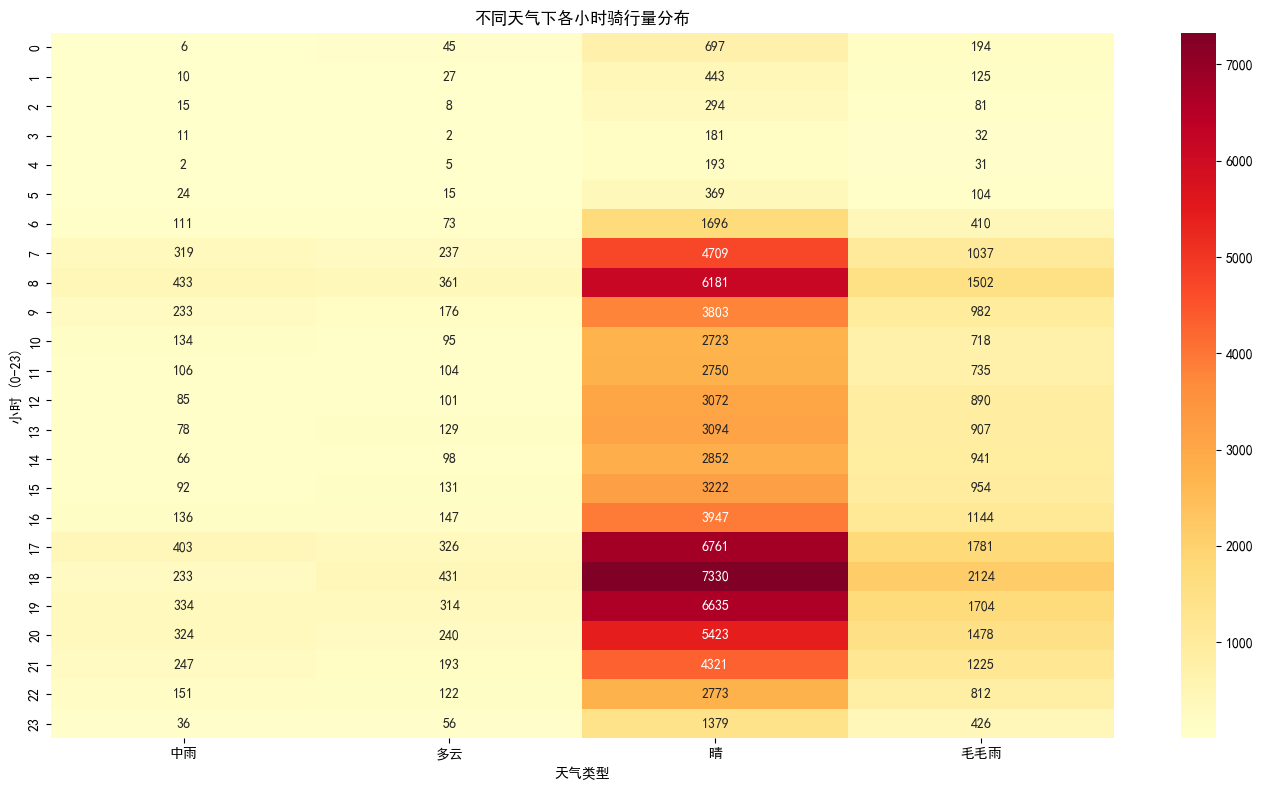

In [17]:
# 绘制热力图
plt.figure(figsize=(14,8))
sns.heatmap(hour_weather_pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('不同天气下各小时骑行量分布')
plt.xlabel('天气类型')
plt.ylabel('小时 (0-23)')
plt.tight_layout()
plt.show()

##B4 空间分布分析

In [43]:
# 对起始经纬度进行分组聚合，统计每个位置点的订单数量
# 保留小数点后2位作为近似位置
df['start_lat_round'] = df['start_location_y(°)'].round(2)
df['start_lon_round'] = df['start_location_x(°)'].round(2)

# 统计每个位置点的骑行量（全部点）
start_points = df.groupby(['start_lon_round', 'start_lat_round']).size().reset_index(name='count')

print(start_points)

      start_lon_round  start_lat_round  count
0              121.17            31.36      1
1              121.18            31.37      1
2              121.19            31.15      1
3              121.19            31.16      1
4              121.21            31.42      1
...               ...              ...    ...
1162           121.74            31.04      1
1163           121.75            31.05      1
1164           121.78            31.20      1
1165           121.93            30.91      1
1166           121.97            30.88      1

[1167 rows x 3 columns]


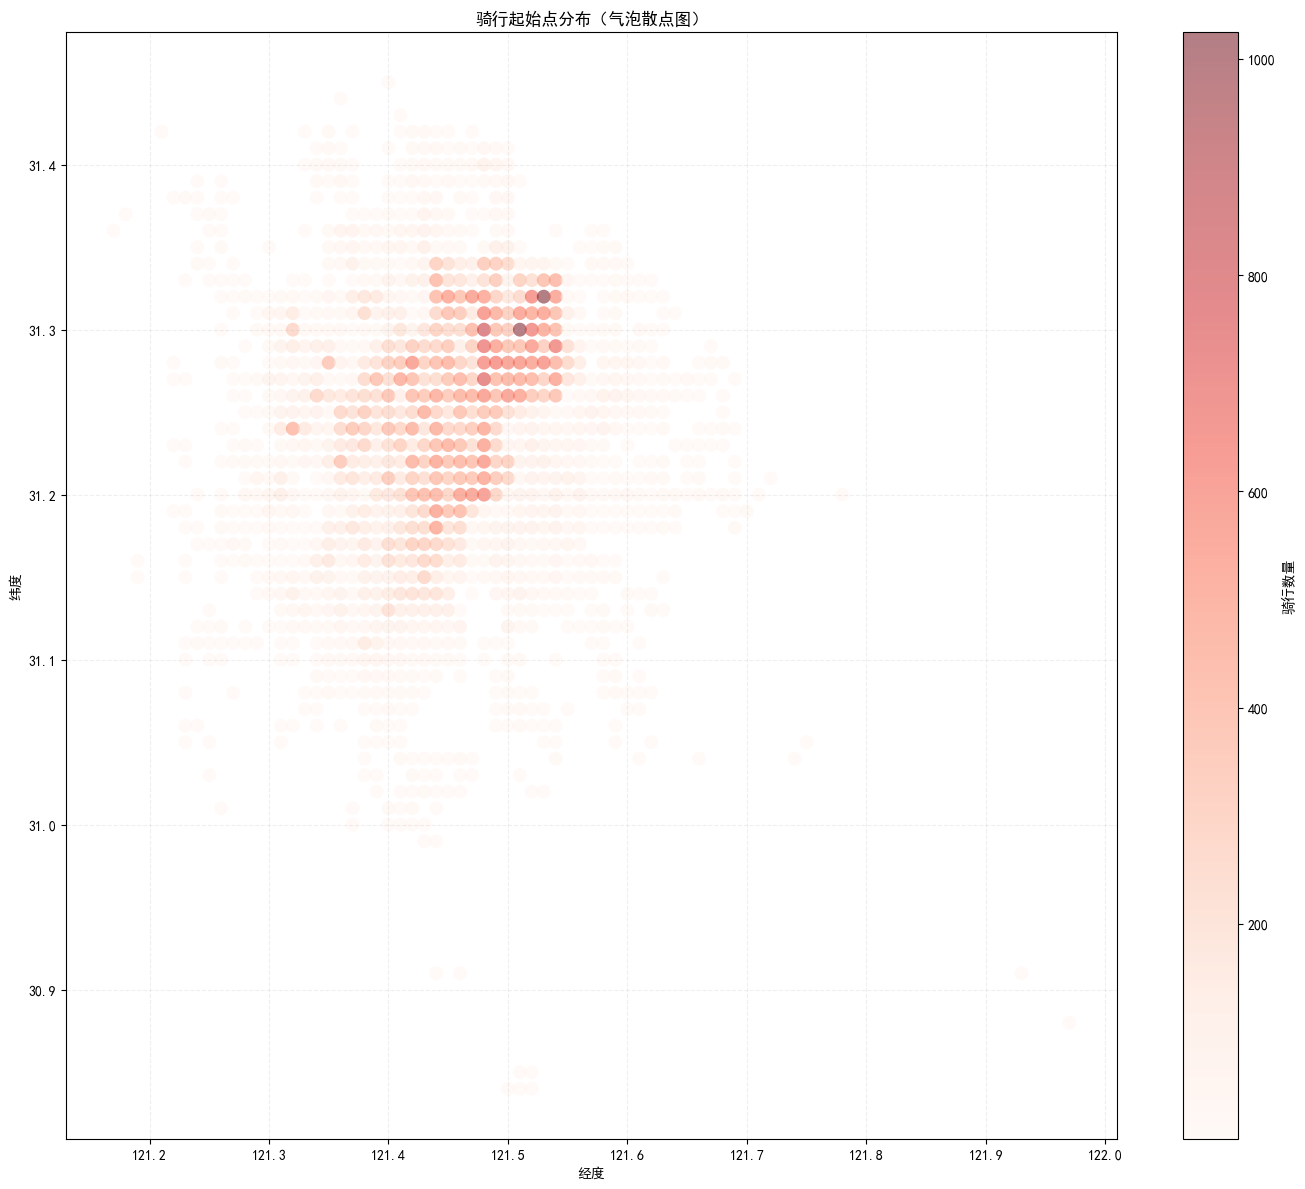

骑行量最多的5个起始点：
     start_lon_round  start_lat_round  count count_bin
895           121.53            31.32   1025         高
836           121.51            31.30   1010         高
731           121.48            31.30    809         高
728           121.48            31.27    746         高
730           121.48            31.29    681         高


In [46]:
# 绘制气泡散点图（全部点）
plt.figure(figsize=(14,12))


scatter = plt.scatter(
    start_points['start_lon_round'], 
    start_points['start_lat_round'],
    c=start_points['count'],
    s=100,
    alpha=0.5,          # 降低透明度，观察重叠区域
    cmap='Reds',
    edgecolors='none',  # 去掉边框，减少视觉干扰
)

cbar = plt.colorbar(scatter, label='骑行数量')
cbar.ax.tick_params(labelsize=10)

plt.title('骑行起始点分布（气泡散点图）')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# 输出订单量最多的5个起始点（用于了解热点）
print("骑行量最多的5个起始点：")
print(start_points.nlargest(5, 'count'))